# NSD数据代码使用demo 
NSD 数据手册: https://cvnlab.slite.page/p/NKalgWd__F/

以下代码基于clip2brain改编：https://github.com/ariaaay/clip2brain 

Wang, A.Y., Kay, K., Naselaris, T. et al. Better models of human high-level visual cortex emerge from natural language supervision with a large and diverse dataset. *Nat Mach Intell 5*, 1415–1426 (2023). https://doi.org/10.1038/s42256-023-00753-y

## 下载数据

下载数据要通过amazon S3，推荐使用数据手册中Cyberduck可视化方法下载。https://cvnlab.slite.page/p/dC~rBTjqjb/How-to-get-the-data

NSD中数据繁多，按照clip2brain的代码，需要的数据为：

1.ROI（感兴趣区域）路径为 nsddata/ppdata/subjAA/func1pt8mm，路径下包含标准分辨率1.8毫米fmri数据 具体数据解释 https://cvnlab.slite.page/p/L5ZIbre~Zf/Functional-data-general   
ROI详情 https://cvnlab.slite.page/p/X_7BBMgghj/ROIs

2.beta值（体素对一个刺激的平均激活强度），路径为 nsddata_betas/ppdata/subjAA/func1pt8mm/betas_fithrf_GLMdenoise_RR，路径下为beta version3数据，
version3是针对每个voxel特定的血氧动力函数，加上l2正则化拟合出的beta值，精度更为准确，具体解释 https://cvnlab.slite.page/p/6CusMRYfk0/Functional-data-NSD  中Results of single-trial GLM部分

3.实验刺激信息，路径为 nsddata/experiments/nsd/nsd_stim_info_merged.pkl，包含刺激的cocoid对应实验中的出现试次等信息，具体解释见 https://cvnlab.slite.page/p/NKalgWd__F/Experiments。

## FMRI数据
### 提取激活和ROI
修改config中文件路径，此处示范为当前目录下subj01的第一个session，每个被试具体的信息参见：https://cvnlab.slite.page/p/h_T_2Djeid/Technical-notes

In [ ]:
import nibabel as nib
beta_file = nib.load("%s/betas_session%02d.nii.gz" % ("nsddata_betas/ppdata/subj01/func1pt8mm/betas_fithrf_GLMdenoise_RR/", 1))
beta = beta_file.get_fdata()
beta.shape

(81, 104, 83, 750)

In [ ]:
!python extract_cortical_voxel.py --zscore_by_run --subj 1 #提取皮层beta值，每一个run计算Z score

  2%|█                                           | 1/40 [00:07<04:59,  7.68s/it]
NaN Values:False
Is finite:True
Zscoring...
100%|███████████████████████████████████████████| 12/12 [00:02<00:00,  5.36it/s]
Is finite:True


输出 output/cortical_voxels/cortical_voxel_across_sessions_zscored_by_run_subj01.npy；output/voxels_masks/subj1/cortical_mask_subj01.npy；

In [3]:
import numpy as np
zbeta = np.load('output/cortical_voxels/cortical_voxel_across_sessions_zscored_by_run_subj01.npy')
print('beta shape:',zbeta.shape) #(trial个数,皮层voxel个数)
cmask = np.load('output/voxels_masks/subj1/cortical_mask_subj01.npy') #True or False构成
print('cortical mask shape:',cmask.shape) 

beta shape: (750, 107104)
cortical mask shape: (81, 104, 83)


### ROI list 
具体参考 https://cvnlab.slite.page/p/X_7BBMgghj/ROIs

"floc-words": word_roi_names, "floc-faces": face_roi_names

"floc-places": place_roi_names, "floc-bodies": body_roi_names

"prf-visualrois": visual_roi_names, "prf-eccrois": ecc_roi_names

"Kastner2015": kastner_roi_names, "HCP_MMP1": hcp_roi_names, "language": language_roi_names



In [ ]:
!python extract_cortical_voxel.py --subj 1 --mask_only --roi floc-faces #提取ROI mask

Extracting ROI floc-faces for subj1
from NSD general, cortical voxel number is: 107104.
Number of non-zero ROI voxels: 1308
Number of cortical voxels is: 107104


In [3]:
roi_faces_1d = np.load("output/voxels_masks/subj1/roi_1d_mask_subj01_floc-faces.npy")
print('1D faces roi shape:',roi_faces_1d.shape)
roi_faces = np.load("output/voxels_masks/subj1/cortical_mask_subj01_floc-faces.npy")
print('faces roi shape:',roi_faces.shape)

1D faces roi shape: (107104,)
faces roi shape: (81, 104, 83)


Text(0.5, 0.98, 'Center slices for cortical image')

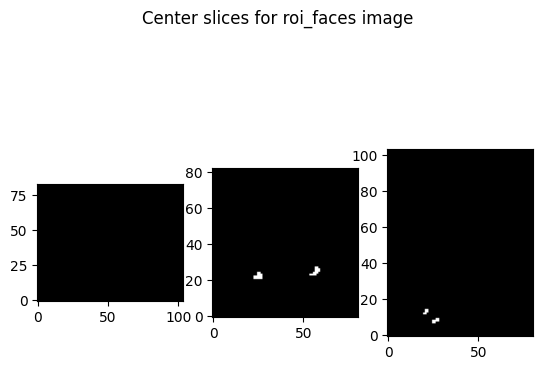

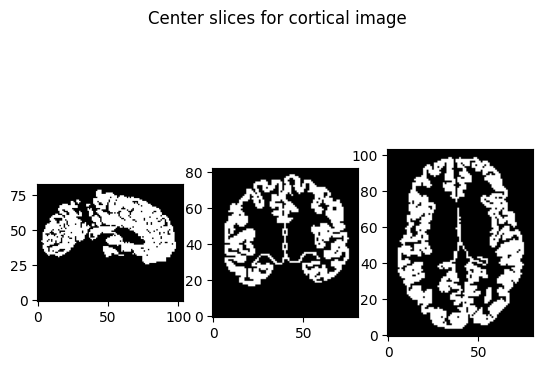

In [4]:
#看一看face的roi
import matplotlib.pyplot as plt
def show_slices(slices):
   """ Function to display row of image slices """
   fig, axes = plt.subplots(1, len(slices))
   for i, slice in enumerate(slices):
       axes[i].imshow(slice.T, cmap="gray", origin="lower")

faces_0 = roi_faces[40, :, :]
faces_1 = roi_faces[:, 52, :]
faces_2 = roi_faces[:, :, 41]
show_slices([faces_0, faces_1, faces_2])
plt.suptitle("Center slices for roi_faces image")  

slice_0 = cmask[40, :, :]
slice_1 = cmask[:, 52, :]
slice_2 = cmask[:, :, 41]
show_slices([slice_0, slice_1, slice_2])
plt.suptitle("Center slices for cortical image")  

In [ ]:
zbeta[:,roi_faces_1d] #roi下的beta值

## COCO图片数据
具体的对应表如下

In [7]:
import pandas as pd
stim_info_path = "./nsddata/experiments/nsd/nsd_stim_info_merged.pkl"
stim_info = pd.read_pickle(stim_info_path)
stim_info.head()

,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,...,subject5_rep2,subject6_rep0,subject6_rep1,subject6_rep2,subject7_rep0,subject7_rep1,subject7_rep2,subject8_rep0,subject8_rep1,subject8_rep2
0,532481,val2017,"(0, 0, 0.1671875, 0.1671875)",0.100000,0,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
1,245764,val2017,"(0, 0, 0.125, 0.125)",0.000000,1,False,False,False,0,0,...,0,0,0,0,13985,14176,28603,0,0,0
2,385029,val2017,"(0, 0, 0.125, 0.125)",0.000000,2,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
3,311303,val2017,"(0, 0, 0.16640625, 0.16640625)",0.125000,3,False,False,False,0,0,...,0,0,0,0,0,0,0,0,0,0
4,393226,val2017,"(0, 0, 0.125, 0.125)",0.133333,4,False,False,False,0,0,...,0,13720,22861,23023,0,0,0,0,0,0


翻译源自：https://cvnlab.slite.page/p/NKalgWd__F/Experiments

第 10-17 列（subjectX）为 0 或 1，表示是否向受试者 X 展示过该图像（X 的范围为 1-8）。

第 18-41 列（subjectX_repN）为 0，表示未向受试者 X 展示图像，或者为正整数 T，表示在重复 N 时向受试者 X 展示了图像（X 范围为 1-8；N 范围为 0-2，共 3 次试验）。T 提供了与图像显示相关的试验 ID。trialID 是一个基于 1 的索引，从 1 到 30000，与受试者在 NSD 实验过程中遇到的所有 30000 次刺激试验的时间顺序相对应。在 73k 张 NSD 图像中，每张图像都有 3 个 trialID（如果只向一个受试者展示）或 24 个 trialID（如果向所有 8 个受试者展示）。

In [ ]:
!python extract_image_list.py --subj 1 --type trial #序号为0-based 提取出3次重复中被试1的图片trailID

In [8]:
trailID = np.load("output/trials_subj01.npy") # size should be 10000 by 3 for subj 1,2,5,7; ordered by image id. entries are trial numbers
trailID.shape

(10000, 3)

In [ ]:
!python extract_image_list.py --subj 1 --type cocoId #三次重复中，cocoid应该相同

In [4]:
Coco_id = np.load("output/coco_ID_of_repeats_subj01.npy")
Coco_id.shape

(10000,)

In [31]:
print('被试1 按表中NSDID顺序 第一张图片对应的三次重复trialID为',trailID[0,:],'这张图片的cocoID是',Coco_id[0,])

被试1 按表中NSDID顺序 第一张图片对应的三次重复trialID为 [  841 17595 17836] 这张图片的cocoID是 24610


In [ ]:
stim_info["subject1_rep0"][stim_info["cocoId"] == 24610] #大1因为表里为1-30000编码

13    842
Name: subject1_rep0, dtype: int64

In [ ]:
# stim_info[
#     (stim_info['subject1'] == 1) &
#     (stim_info["subject1_rep0"] < 750) &
#     (stim_info["subject1_rep1"] < 750) &
#     (stim_info["subject1_rep2"] < 750)
# ].iloc[:, :20]

### 对齐beta和stimuli表中的顺序
此处为了演示，有大量的nan值

In [11]:
from tqdm import tqdm

repeat_n = trailID.shape[0]
# data size is # of total trials X # of voxels

avg_mat = np.zeros(
    (repeat_n, zbeta.shape[1])
)  # size = number of repeated images by number of voxels

print("Brain data shape is:")
print(zbeta.shape)
# import pdb; pdb.set_trace()
# fill in 0s for nonexisting trials
if zbeta.shape[0] < 30000:
    tmp = np.zeros((30000, zbeta.shape[1]))
    tmp[:] = np.nan
    tmp[: zbeta.shape[0], :] = zbeta.copy()
    zbeta = tmp

for v in tqdm(range(zbeta.shape[1])):  # loop over voxels
    repeat = list()
    for r in range(3):
        try:
            repeat.append(zbeta[trailID[:, r], v])  # all repeated trials for each voxels 将原来的根据trail顺序的beta 变成 根据nsdid顺序相同同的beta
        except IndexError:
            print("Index Error")
            print(r, v)

    # repeat size: 3 x # repeated images
    repeat = np.array(repeat).T
    try:
        assert repeat.shape == (repeat_n, 3)
        avg_mat[:, v] = np.nanmean(repeat, axis=1)
        # print("NaNs:")
        # print(np.sum(np.isnan(avg_mat[:, v])))
    except AssertionError:
        print(repeat.shape)

np.save(
    "./output/cortical_voxels/averaged_cortical_responses_zscored_by_run_subj01.npy",
    avg_mat
)

Brain data shape is:
(30000, 107104)


  0%|          | 0/107104 [00:00<?, ?it/s]/var/folders/tx/y84lcskj0qv1_4cx70366s2m0000gn/T/ipykernel_2877/1823788114.py:33: RuntimeWarning: Mean of empty slice
  avg_mat[:, v] = np.nanmean(repeat, axis=1)
100%|██████████| 107104/107104 [02:06<00:00, 844.61it/s]


In [6]:
oravezbeta = np.load("./output/cortical_voxels/averaged_cortical_responses_zscored_by_run_subj01.npy")
oravezbeta.shape #此时的zbeta第一维度顺序和Coco_id所对应的图片顺序是相同的

(10000, 107104)

In [7]:
valid_idx = ~np.all(np.isnan(oravezbeta), axis=1) #提取第二维度不全为nan的
indices = np.where(valid_idx)[0]

In [8]:
indices.shape #第一个被试的session1中总共看了583个刺激，有些重复有些不重复

(583,)

In [9]:
Coco_id[valid_idx][0:5]

array([295316, 492077, 225405, 500826, 530061])

按照nsdid顺序排列，第一个beta所对应的Cocoid为295316，是在第138个trial中展现的,后续也如此对应

In [40]:
stim_info[(stim_info['subject1'] == 1) & (stim_info['subject1_rep0'] <750 ) ].iloc[:5,:20]

,cocoId,cocoSplit,cropBox,loss,nsdId,flagged,BOLD5000,shared1000,subject1,subject2,subject3,subject4,subject5,subject6,subject7,subject8,subject1_rep0,subject1_rep1,subject1_rep2,subject2_rep0
155,295316,val2017,"(0, 0, 0.125, 0.125)",0.000000,155,False,False,False,1,0,0,0,0,0,0,0,138,1587,21465,0
204,492077,val2017,"(0, 0, 0.125, 0.125)",0.076923,204,False,False,False,1,0,0,0,0,0,0,0,112,11263,17267,0
266,225405,val2017,"(0, 0, 0.13203125, 0.13203125)",0.000000,266,False,False,False,1,0,0,0,0,0,0,0,635,18521,19040,0
409,500826,val2017,"(0, 0, 0.1671875, 0.1671875)",0.000000,409,False,False,False,1,0,0,0,0,0,0,0,342,15328,15338,0
488,530061,val2017,"(0, 0, 0.0, 0.2890625)",0.142857,488,False,False,False,1,0,0,0,0,0,0,0,678,1349,22207,0
